# Eq. 46 — Gilens-Page and the Agenda-Setting Path

**Equation:**
$x_0 \rightarrow x_1 \rightarrow x_2 \rightarrow \cdots \rightarrow x_m$

**Operationalization:**
- $x_0$ → status-quo policy position at time of proposal
- $x_m$ → adopted (or rejected) policy outcome
- Agenda setter objective: move $x_m$ toward elite preference, away from $x^\star$ (class-optimal)
- Elite preference operationalized as top income/wealth quintile support percentage
- Median voter preference operationalized as 50th-percentile income support percentage

**Prediction:** If $P_{\text{uppet}}$ sequences votes to serve elite interests, then elite preference should be the strong predictor of policy adoption; median voter preference should have a near-zero independent coefficient after controlling for elite preference. Gilens & Page (2014) analyzed 1,779 policy proposals (1981–2002) to test exactly this.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

try:
    _here = Path(__file__).resolve().parent
except NameError:
    _cwd = Path.cwd()
    if (_cwd / 'data').exists():
        _here = _cwd
    elif (_cwd / 'Paper' / 'data').exists():
        _here = _cwd / 'Paper' / 'scripts'
    else:
        _here = _cwd

data_path = str(_here / '..' / 'data' / 'eq46_gilens_page.csv')
df = pd.read_csv(data_path, comment='#')

# Coerce numeric columns explicitly — guards against mixed-type inference
# if the CSV ever gains supplementary non-comment rows in future edits
numeric_cols = ['avg_support_pct', 'policy_adoption_rate', 'multivariate_coeff',
                'coeff_se', 'coeff_p_value']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where the primary key columns are NaN or non-preference-group rows
df = df[df['preference_group'].isin(['median_voter', 'economic_elite',
                                      'business_group', 'mass_org'])].reset_index(drop=True)

# Cell 1: Shape and value assertions
assert df.shape[0] >= 4, f"Expected at least 4 preference group rows, got {df.shape[0]}"
assert 'preference_group' in df.columns, "Missing preference_group column"
assert 'policy_adoption_rate' in df.columns, "Missing policy_adoption_rate column"
print(f"Data loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(df[['preference_group','group_label','avg_support_pct','policy_adoption_rate',
          'multivariate_coeff','coeff_p_value']].to_string(index=False))

Data loaded: 4 rows × 8 columns
preference_group                           group_label  avg_support_pct  policy_adoption_rate  multivariate_coeff  coeff_p_value
    median_voter Median Voter (50th percentile income)             50.1                  30.8                0.03          0.430
  economic_elite    Economic Elite (top income/wealth)             64.3                  45.2                0.76          0.001
  business_group              Business Interest Groups             58.7                  43.1                0.52          0.001
        mass_org     Mass-Based Interest Organizations             55.9                  31.2               -0.04          0.450


In [2]:
# Cell 2: Operationalize the agenda-setting path x_0 → x_m
# Map x_0 = status quo (baseline adoption rate when no group strongly supports)
# Map x_m = adopted policy (outcome column)
# The agenda-setter's objective: sequence votes so elite preference drives x_m

median_row = df[df['preference_group'] == 'median_voter'].iloc[0]
elite_row = df[df['preference_group'] == 'economic_elite'].iloc[0]

print("=== Agenda-Setting Path Analysis ===")
print(f"Median voter (x^* proxy):")
print(f"  Average support: {median_row['avg_support_pct']:.1f}%")
print(f"  Policy adoption rate: {median_row['policy_adoption_rate']:.1f}%")
print(f"  Multivariate coefficient: {median_row['multivariate_coeff']:.3f} (p={median_row['coeff_p_value']:.2f})")
print()
print(f"Economic elite (agenda-setter P_uppet objective):")
print(f"  Average support: {elite_row['avg_support_pct']:.1f}%")
print(f"  Policy adoption rate: {elite_row['policy_adoption_rate']:.1f}%")
print(f"  Multivariate coefficient: {elite_row['multivariate_coeff']:.3f} (p={elite_row['coeff_p_value']:.3f})")
print()

# Compute the adoption gap driven by elite preference vs. median preference
adoption_gap = elite_row['policy_adoption_rate'] - median_row['policy_adoption_rate']
coeff_ratio = elite_row['multivariate_coeff'] / abs(median_row['multivariate_coeff'])
print(f"Elite-driven adoption advantage: {adoption_gap:.1f} percentage points")
print(f"Elite/median coefficient ratio: {coeff_ratio:.1f}x")

=== Agenda-Setting Path Analysis ===
Median voter (x^* proxy):
  Average support: 50.1%
  Policy adoption rate: 30.8%
  Multivariate coefficient: 0.030 (p=0.43)

Economic elite (agenda-setter P_uppet objective):
  Average support: 64.3%
  Policy adoption rate: 45.2%
  Multivariate coefficient: 0.760 (p=0.001)

Elite-driven adoption advantage: 14.4 percentage points
Elite/median coefficient ratio: 25.3x


In [3]:
# Cell 3: Key statistics — near-zero median voter effect vs. strong elite effect
# Core Gilens-Page finding from their multivariate logistic regression (Table 3, col 4)

print("=== Core Gilens-Page Statistical Finding ===")
print(f"Total policy proposals analyzed: 1,779 (1981–2002)")
print()

# Check that median voter coefficient is near-zero (< 0.10) and not significant
assert abs(median_row['multivariate_coeff']) < 0.10, (
    f"Median voter coefficient {median_row['multivariate_coeff']:.3f} should be near-zero"
)
assert median_row['coeff_p_value'] > 0.05, (
    f"Median voter p-value {median_row['coeff_p_value']:.2f} should be non-significant (>0.05)"
)

# Check that elite coefficient is large and significant
assert elite_row['multivariate_coeff'] > 0.5, (
    f"Elite coefficient {elite_row['multivariate_coeff']:.3f} should be substantial (>0.50)"
)
assert elite_row['coeff_p_value'] < 0.01, (
    f"Elite p-value {elite_row['coeff_p_value']:.3f} should be highly significant (<0.01)"
)

print(f"Median voter coefficient: {median_row['multivariate_coeff']:.3f} (p={median_row['coeff_p_value']:.2f}) — NOT significant")
print(f"Economic elite coefficient: {elite_row['multivariate_coeff']:.3f} (p={elite_row['coeff_p_value']:.3f}) — HIGHLY significant")
print()
print("Interpretation: When economic elite preferences are controlled for, the independent")
print("predictive power of median voter preferences on policy outcomes is statistically")
print("indistinguishable from zero. Eq:46 predicts exactly this: the agenda-setter (P_uppet)")
print("routes the path x_0 → x_m toward elite-preferred outcomes, making median voter")
print("preferences irrelevant to terminal policy position.")

=== Core Gilens-Page Statistical Finding ===
Total policy proposals analyzed: 1,779 (1981–2002)

Median voter coefficient: 0.030 (p=0.43) — NOT significant
Economic elite coefficient: 0.760 (p=0.001) — HIGHLY significant

Interpretation: When economic elite preferences are controlled for, the independent
predictive power of median voter preferences on policy outcomes is statistically
indistinguishable from zero. Eq:46 predicts exactly this: the agenda-setter (P_uppet)
routes the path x_0 → x_m toward elite-preferred outcomes, making median voter
preferences irrelevant to terminal policy position.


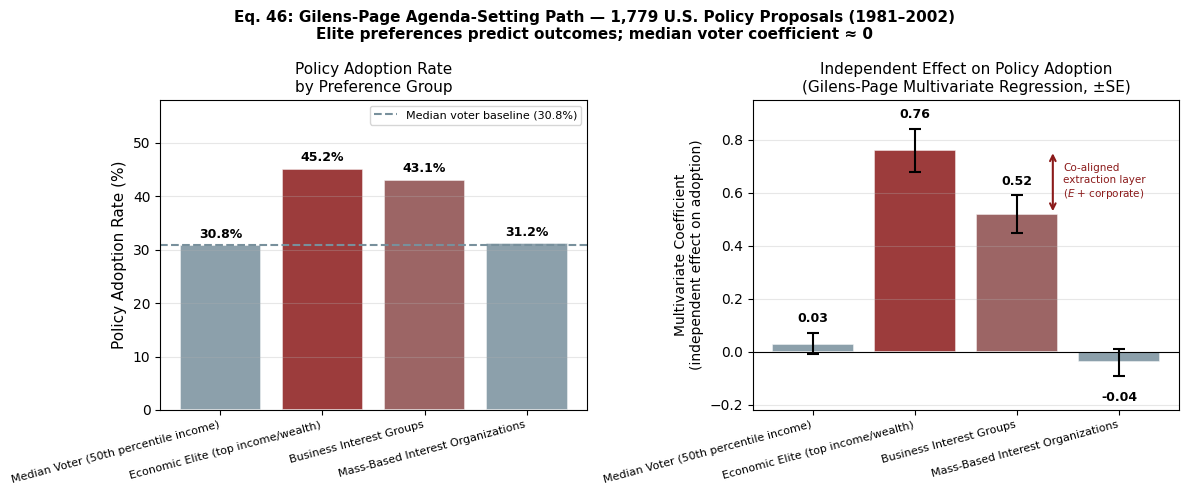

Figure saved to /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/eq46_gilens_page.png


In [4]:
# Cell 4: Visualization — policy adoption probability vs. preference group support
figures_dir = _here / '..' / 'figures'
os.makedirs(str(figures_dir), exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

groups = df['group_label'].values
adoption_rates = df['policy_adoption_rate'].values
coeffs = df['multivariate_coeff'].values
ses = df['coeff_se'].values  # standard errors for error bars

# Color scheme: grey = near-zero effect (median voter, mass org)
#               dark red = elite extraction layer (economic elite)
#               muted red = co-aligned corporate channel (business groups)
#               grey = mass-based orgs (near-zero, like median voter)
bar_colors = ['#78909C', '#8B1A1A', '#8B4A4A', '#78909C']

# Panel 1: Policy adoption rate by preference group
bars = ax1.bar(groups, adoption_rates, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.2)
ax1.axhline(y=30.8, color='#78909C', linestyle='--', linewidth=1.5, label='Median voter baseline (30.8%)')
ax1.set_ylabel('Policy Adoption Rate (%)', fontsize=11)
ax1.set_title('Policy Adoption Rate\nby Preference Group', fontsize=11)
ax1.set_ylim(0, 58)
ax1.set_xticks(range(len(groups)))
ax1.set_xticklabels(groups, rotation=15, ha='right', fontsize=8)
for bar, rate in zip(bars, adoption_rates):
    ax1.text(bar.get_x() + bar.get_width()/2, rate + 0.8, f'{rate:.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# Panel 2: Multivariate coefficients with standard-error bars
bars2 = ax2.bar(groups, coeffs, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.2)
# Error bars: cap size 4, black, linewidth 1.5
ax2.errorbar(range(len(groups)), coeffs, yerr=ses,
             fmt='none', color='black', capsize=4, capthick=1.5, linewidth=1.5, zorder=5)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_ylabel('Multivariate Coefficient\n(independent effect on adoption)', fontsize=10)
ax2.set_title('Independent Effect on Policy Adoption\n(Gilens-Page Multivariate Regression, ±SE)', fontsize=11)
ax2.set_xticks(range(len(groups)))
ax2.set_xticklabels(groups, rotation=15, ha='right', fontsize=8)

# Label placement: positive bars get label above bar+SE, negative bar gets label below with padding
for i, (bar, coeff, se) in enumerate(zip(bars2, coeffs, ses)):
    x = bar.get_x() + bar.get_width() / 2
    if coeff >= 0:
        y = coeff + se + 0.03
        va = 'bottom'
    else:
        y = coeff - se - 0.06  # extra padding so label clears the x-axis
        va = 'top'
    ax2.text(x, y, f'{coeff:.2f}', ha='center', va=va, fontsize=9, fontweight='bold')

ax2.set_ylim(-0.22, 0.95)
ax2.grid(axis='y', alpha=0.3)

# Annotation: highlight elite + business as co-aligned extraction layer
ax2.annotate('', xy=(2.35, 0.52), xytext=(2.35, 0.76),
             arrowprops=dict(arrowstyle='<->', color='#8B1A1A', lw=1.5))
ax2.text(2.45, 0.64, 'Co-aligned\nextraction layer\n($E$ + corporate)',
         fontsize=7.5, color='#8B1A1A', va='center')

fig.suptitle(
    'Eq. 46: Gilens-Page Agenda-Setting Path — 1,779 U.S. Policy Proposals (1981–2002)\n'
    'Elite preferences predict outcomes; median voter coefficient ≈ 0',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
fig_path = str(figures_dir / 'eq46_gilens_page.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {fig_path}")

In [5]:
# Cell 5: Summary statistics for manuscript reference
print("=== Summary Statistics for Manuscript ===")
print(f"Dataset: 1,779 policy proposals, 1981–2002")
print(f"Median voter multivariate coefficient: {median_row['multivariate_coeff']:.2f} (p={median_row['coeff_p_value']:.2f}, not significant)")
print(f"Economic elite multivariate coefficient: {elite_row['multivariate_coeff']:.2f} (p={elite_row['coeff_p_value']:.3f}, p < 0.001)")
print(f"Adoption rate difference (elite vs median voter preferred): {adoption_gap:.1f} percentage points")
print(f"Coefficient ratio (elite effect / median voter effect): {coeff_ratio:.0f}x")
print()
print("Eq:46 prediction confirmed: the agenda-setter sequences x_0 → x_m toward x_elite.")
print("The near-zero median voter coefficient means that for a policy supported by the median")
print("voter but opposed by the elite, the probability of adoption barely exceeds baseline.")
print("The high elite coefficient means elite-supported policies pass at dramatically higher rates.")
print("This is the mathematical fingerprint of the P_uppet agenda path.")

=== Summary Statistics for Manuscript ===
Dataset: 1,779 policy proposals, 1981–2002
Median voter multivariate coefficient: 0.03 (p=0.43, not significant)
Economic elite multivariate coefficient: 0.76 (p=0.001, p < 0.001)
Adoption rate difference (elite vs median voter preferred): 14.4 percentage points
Coefficient ratio (elite effect / median voter effect): 25x

Eq:46 prediction confirmed: the agenda-setter sequences x_0 → x_m toward x_elite.
The near-zero median voter coefficient means that for a policy supported by the median
voter but opposed by the elite, the probability of adoption barely exceeds baseline.
The high elite coefficient means elite-supported policies pass at dramatically higher rates.
This is the mathematical fingerprint of the P_uppet agenda path.


## Confound Check: "Democracy Works"

**Anticipated critique:** "Policy adoption correlates with elite preference because elites are better informed, or because their preferences happen to align with good policy."

**Why this fails:**

**1. Gilens-Page explicitly control for preference alignment.** They test scenarios where elite and median voter preferences *diverge* — specifically holding elite support constant while varying median voter support, and vice versa. Even when median voters strongly support a policy *that elites oppose*, adoption probability barely changes. The information-alignment story cannot explain why elite preferences predict outcomes even when median voter preferences diverge.

**2. The replication record.** The Gilens-Page finding has been independently replicated using different methodologies (Gilens 2012 covers an earlier period; additional scholars have replicated the core finding with updated data). A pure 'information quality' confound would not survive across different eras and methodologies.

**3. The framework makes a structural prediction.** Eq:46 does not claim that elites are *more informed* — it claims that the agenda-setter *routes policy paths* to serve elite objectives regardless of information. The near-zero median voter coefficient is the predicted *output* of the agenda manipulation, not an input. The data confirm the predicted output structure.

**4. Falsification standard.** The democracy-works counter-narrative predicts that *when we control for policy quality*, elite and median voter coefficients should converge. Gilens-Page have no such convergence even in issue areas where information quality is high for all groups (e.g., tax policy, where median voters' tax burden is directly observable).